# Contents

1. Load XGBoost and NN models
2. Explore model performance
3. Ensemble model objective & method
4. Ensemble model implementation
5. Evaluation
6. Plots
7. Appendix

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, log_loss, precision_recall_curve,
    precision_score, recall_score, roc_curve, auc
)

import xgboost as xgb
from tensorflow.keras.models import load_model as keras_load_model

In [48]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Load XGBoost and NN models

In [49]:
nn_keras_path = "../models/NN/NN_1to10_all.keras"
nn_model = keras_load_model(nn_keras_path)

In [50]:
xgb_json_path = "../models/XGB/best_xgb_1to10_all.json"
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(xgb_json_path)

## Explore model performance

Based on our validation data, we evaluate the performance of both the XGBoost and NN models. As the two models have different input types, we have separate data preparation pipelines, although the underlying data used is the same.

In [51]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_downsampled_1to10_with_merchants.csv')
df_val = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

In [52]:
df_train_xgb = df_train.copy()
df_train_nn = df_train.copy()

df_val_xgb = df_val.copy()
df_val_nn = df_val.copy()

df_test_xgb = df_test.copy()
df_test_nn = df_test.copy()

### Data preparation for XGBoost

In [53]:
print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'transaction_sequence', 'isFlaggedFraud', 'typeHighValueFlag', 'amountBucket', 
]

for col in categorical_cols:
    # Combine categories from both train, val and test, to avoid unseen categories during inference 
    combined_cats = pd.Series(
        pd.concat([df_train_xgb[col], df_val_xgb[col], df_test_xgb[col]], axis=0).dropna().unique()
    )
    categories = sorted(combined_cats.unique())

    df_train_xgb[col] = pd.Categorical(df_train[col], categories=categories)
    df_val_xgb[col]   = pd.Categorical(df_val[col], categories=categories)
    df_test_xgb[col]  = pd.Categorical(df_test[col], categories=categories)

Converting categorical columns ...


In [54]:
# selected features for all
selected_features = [
    # transaction-level features
    'step', 'type', 'hourOfDay', 'day', 'amountLog', 'dayOfWeek', 'amount', 
    'oldbalanceOrg', 'oldbalanceDest',
    'amount_to_oldbalanceOrg',
     
                
    # account-level features
    'meanSent', 
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived',  'numReceived', 
    'stdReceived', 'meanReceived', 
    'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 
    'avgAmountToDest', 
    'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig', 

    # transaction pattern features 
    'transaction_sequence', 'sequence_frequency', 'transactionRecency', 'typeHighValueFlag', 
    'is_early_transaction',  'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # centrality features
    'sender_btwn', 'receiver_btwn', 'btwn_diff', 
    'sender_outdeg_amt', 'sender_indeg_amt', 'receiver_outdeg_amt', 'receiver_indeg_amt',
    'sender_outdeg_cnt', 'sender_indeg_cnt', 'receiver_outdeg_cnt', 'receiver_indeg_cnt', 
    'outdeg_amt_diff', 'indeg_amt_diff',
    'outdeg_cnt_diff', 'indeg_cnt_diff' 
]

In [55]:
print("Processing training set ...")
Xtrain_xgb, ytrain_xgb = df_train_xgb[selected_features].copy(), df_train_xgb["isFraud"].astype(int)

print("Processing validation set ...")
Xval_xgb, yval_xgb = df_val_xgb[selected_features].copy(), df_val_xgb["isFraud"].astype(int)

print("Processing test set ...")
Xtest_xgb, ytest_xgb = df_test_xgb[selected_features].copy(), df_test_xgb["isFraud"].astype(int)

print("Done!")

Processing training set ...
Processing validation set ...
Processing test set ...
Done!


### Data preparation for NN

In [56]:
selected_features = [
    # transaction-level features
    'step', 'type', 'day', 'amountLog', 'amount_to_oldbalanceOrg','dayOfWeek','hourOfDay',
    # 'amount',         
                
    # account-level features
    'meanSent', 'numUniqueDest', 'numUniqueOrig',
    'transaction_sequence',
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'maxAmountReceived', 
    'stdAmountReceived', 'avgAmountToDest', 'std_to_mean_ratio', 
    'pctForwarded24h', 'oldbalanceOrg', 'oldbalanceDest',

    # transaction pattern features
    'transactionRecency', 'is_early_transaction',  'sequence_frequency', 'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # aggregated risk signals
    'typeHighValueFlag', 

    # centrality features
    "receiver_indeg_amt",
    "sender_outdeg_amt","sender_indeg_amt", "receiver_outdeg_amt",
    "sender_outdeg_cnt","sender_indeg_cnt", "receiver_outdeg_cnt","receiver_indeg_cnt",
    "outdeg_amt_diff","indeg_amt_diff", "outdeg_cnt_diff","indeg_cnt_diff", 'sender_btwn',
    'receiver_btwn', 'btwn_diff'
]

In [57]:
len(selected_features)

52

In [58]:
missing_features = [col for col in df_train_nn.columns if col not in selected_features]
print("Missing features:", missing_features)

Missing features: ['amount', 'nameOrig', 'nameDest', 'isFlaggedFraud', 'isFraud', 'avgAmountPerType', 'p95AmountPerType', 'amountBucket', 'fraudProbabilityByAmountBin', 'dayOfWeekName', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig']


In [59]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
columns_to_encode = ['type', 'transaction_sequence', 'typeHighValueFlag']


encoder.fit(df_train[columns_to_encode])


encoded_train = encoder.transform(df_train_nn[columns_to_encode])
encoded_test = encoder.transform(df_test_nn[columns_to_encode])
encoded_val = encoder.transform(df_val_nn[columns_to_encode])


encoded_columns = encoder.get_feature_names_out(columns_to_encode).tolist()


encoded_df_train = pd.DataFrame(encoded_train, columns=encoded_columns, index=df_train.index)
encoded_df_test = pd.DataFrame(encoded_test, columns=encoded_columns, index=df_test.index)
encoded_df_val = pd.DataFrame(encoded_val, columns=encoded_columns, index=df_val.index)

df_train_nn = pd.concat([df_train_nn, encoded_df_train], axis=1)
df_test_nn = pd.concat([df_test_nn, encoded_df_test], axis=1)
df_val_nn = pd.concat([df_val_nn, encoded_df_val], axis=1)

In [60]:
# remove original categorical names from selected_features and append encoded names
selected_features = [c for c in selected_features if c not in columns_to_encode] + encoded_columns

# drop original categorical columns from dataframes to avoid string columns later
df_train_nn = df_train_nn.drop(columns=columns_to_encode, errors='ignore')
df_test_nn  = df_test_nn.drop(columns=columns_to_encode, errors='ignore')
df_val_nn   = df_val_nn.drop(columns=columns_to_encode, errors='ignore')

In [61]:
# Prepare data
X_train_final = df_train_nn[selected_features].copy()
y_train_final = df_train_nn['isFraud'].copy()
X_test_final = df_test_nn[selected_features].copy()
y_test_final = df_test_nn['isFraud'].copy()
X_val_final = df_val_nn[selected_features].copy()
y_val_final = df_val_nn['isFraud'].copy()

In [62]:
print(f"Training set shape:   {df_train_nn.shape}")
print(f"Test set shape:       {df_test_nn.shape}")
print(f"Validation set shape: {df_val_nn.shape}")

# Check if all have same columns
train_cols = set(df_train_nn.columns)
test_cols = set(df_test_nn.columns)
val_cols = set(df_val_nn.columns)

if train_cols == test_cols == val_cols:
    print("\n✓ All datasets have matching columns!")
else:
    print("\n✗ WARNING: Column mismatch detected!")
    print(f"Columns in train but not test: {train_cols - test_cols}")
    print(f"Columns in test but not train: {test_cols - train_cols}")

print(f"\nFinal feature count: {len(df_train_nn.columns)}")
print(f"Feature names: {df_train_nn.columns.tolist()}")

Training set shape:   (63239, 75)
Test set shape:       (954393, 75)
Validation set shape: (954393, 75)

✓ All datasets have matching columns!

Final feature count: 75
Feature names: ['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'nameDest', 'oldbalanceDest', 'isFlaggedFraud', 'isFraud', 'amount_to_oldbalanceOrg', 'day', 'avgAmountToDest', 'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 'avgAmountPerType', 'p95AmountPerType', 'amountLog', 'amountBucket', 'fraudProbabilityByAmountBin', 'totalSent', 'meanSent', 'stdSent', 'numSent', 'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'numUniqueDest', 'numUniqueOrig', 'transactionRecency', 'sequence_frequency', 'is_cashin_transfer_cashout', 'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 'is_early_transaction', 'sequence_count', 'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pct

In [63]:
print("\nScaling features...(Imbalanced)")

numeric_cols = X_train_final.select_dtypes(include=['number']).columns
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols)
])

Xtrain_nn = preprocessor.fit_transform(X_train_final)
Xtest_nn = preprocessor.transform(X_test_final)
Xval_nn = preprocessor.transform(X_val_final)

# Handle NaN/Inf
Xtrain_nn = np.nan_to_num(Xtrain_nn, nan=0.0, posinf=0.0, neginf=0.0)
Xtest_nn = np.nan_to_num(Xtest_nn, nan=0.0, posinf=0.0, neginf=0.0)
Xval_nn = np.nan_to_num(Xval_nn, nan=0.0, posinf=0.0, neginf=0.0)

ytrain_nn = y_train_final.values.astype(int)
ytest_nn = y_test_final.values.astype(int)
yval_nn = y_val_final.values.astype(int)

print(f"Train: {Xtrain_nn.shape}, Fraud rate: {ytrain_nn.mean():.4f}")
print(f"Val: {Xtest_nn.shape}, Fraud rate: {ytest_nn.mean():.4f}")
print(f"Test: {yval_nn.shape}, Fraud rate: {yval_nn.mean():.4f}")


Scaling features...(Imbalanced)


/Users/charlesgoek/Documents/Work/DSA4263 Project/DSA4263/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/charlesgoek/Documents/Work/DSA4263 Project/DSA4263/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/charlesgoek/Documents/Work/DSA4263 Project/DSA4263/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train: (63239, 62), Fraud rate: 0.0909
Val: (954393, 62), Fraud rate: 0.0013
Test: (954393,), Fraud rate: 0.0013


### XGBoost and NN model performance
We look at performance on validation data to see where gaps in each model may lie.

In [64]:
def nn_prob(model, X: np.ndarray) -> np.ndarray:
    p = np.asarray(model.predict(X, verbose=0))
    if p.ndim == 2 and p.shape[1] == 1:  # sigmoid
        return p.ravel()
    if p.ndim == 2 and p.shape[1] == 2:  # softmax
        return p[:, 1]
    if p.ndim == 1:
        return p
    raise ValueError(f"Unexpected Keras output shape: {p.shape}")

def xgb_prob(model: xgb.XGBClassifier, X: np.ndarray) -> np.ndarray:
    p = model.predict_proba(X)
    return p[:, 1] if p.ndim == 2 else p

def calculate_metrics(y_true, p, thr=0.5):
    pred = (p >= thr).astype(int)   
    return {
        "pr_auc":  average_precision_score(y_true, p),
        "f1@thr":  f1_score(y_true, pred, zero_division=0),
        "precision@thr": precision_score(y_true, pred, zero_division=0),
        "recall@thr":    recall_score(y_true, pred, zero_division=0),
        "threshold": float(thr),
    }

def tune_threshold_fbeta(y_true, p, beta=1.0):
    prec, rec, thrs = precision_recall_curve(y_true, p)
    fbeta = (1 + beta**2) * (prec * rec) / np.clip(beta**2 * prec + rec, 1e-12, None)
    fbeta = fbeta[1:]
    idx = int(np.argmax(fbeta))
    return float(thrs[idx]), float(fbeta[idx])


In [65]:
p_xgb_val = xgb_prob(xgb_model, Xval_xgb)

thr_xgb, fbest_xgb = tune_threshold_fbeta(yval_xgb, p_xgb_val, beta=1.0)
base_xgb_val = calculate_metrics(yval_xgb, p_xgb_val, thr=thr_xgb)

print("Validation — Base XGB:", base_xgb_val)

Validation — Base XGB: {'pr_auc': 0.9686821652245494, 'f1@thr': 0.9104175111471423, 'precision@thr': 0.9093117408906882, 'recall@thr': 0.911525974025974, 'threshold': 0.9976503252983093}


In [66]:
p_nn_val  = nn_prob(nn_model, Xval_nn)

thr_nn, fbest_nn = tune_threshold_fbeta(yval_nn, p_nn_val, beta=1.0)
base_nn_val  = calculate_metrics(yval_nn, p_nn_val, thr=thr_nn)

print("Validation — Base NN :", base_nn_val)

Validation — Base NN : {'pr_auc': 0.5408411628886715, 'f1@thr': 0.5469043151969981, 'precision@thr': 0.6477777777777778, 'recall@thr': 0.4732142857142857, 'threshold': 0.9895050525665283}


In [67]:
pred_xgb_val = (p_xgb_val >= thr_xgb).astype(int)
pred_nn_val  = (p_nn_val  >= thr_nn).astype(int)

err_xgb = pred_xgb_val != yval_xgb
err_nn  = pred_nn_val  != yval_nn

both_wrong_cnt     = np.sum(err_xgb & err_nn)
one_model_wrong_cnt = np.sum(err_xgb & ~err_nn) + np.sum(~err_xgb & err_nn)

both_wrong_pct     = np.mean(err_xgb & err_nn)
one_model_wrong_pct = np.mean(err_xgb & ~err_nn) + np.mean(~err_xgb & err_nn)

print(f"Transactions both wrong : {both_wrong_cnt} ({both_wrong_pct*100: .4f}% of cases)")
print(f"Transactions only one wrong : {one_model_wrong_cnt} ({one_model_wrong_pct*100: .4f}% of cases)")

Transactions both wrong : 115 ( 0.0120% of cases)
Transactions only one wrong : 957 ( 0.1003% of cases)


XGBoost performed extremely well, recording >0.9 on PR-AUC, F1, Precision and Recall at its optimal threshold. In contrast, the Neural Network had much lower PR-AUC at 0.541, but only marginally lower accuracy. This may indicate that XGBoost is mostly classifying transactions as non-fraud due to class imbalance rather than the transaction features.

## Ensemble model objective and method


While XGBoost performed far better, the two models are known to capture different types of features, with XGBoost being able to capture nonlinear boundaries and NN being able to capture interactions between different features. Given that the two models commit each commit errors while the other gets it right on 957 (0.1%) cases, combining them could help reduce those remaining mistakes. Additionally, the small overlap in each model's top features gives promise that the models are focusing on different features. In particular, a stacking ensemble could aggregate across both models' strengths and weaknesses, thus improving overall performance if the models are truly capturing different types of information.

Stacking is an ensemble technique where predictions from multiple base models are used as inputs to a meta-model, which learns how to best combine them. In our case, the meta-model (Logistic Regression) learns a set of coefficients that minimize prediction loss on the validation set, effectively determining how much to trust each base model’s output. 

Unlike simple weighted averaging, these weights are not manually fixed but are learned through optimization, resulting in a globally optimal combination of the base models based on their validation performance.

## Ensemble model implementation

In [68]:
p_xgb_test = xgb_prob(xgb_model, Xtest_xgb)
p_nn_test  = nn_prob(nn_model, Xtest_nn)

In [69]:
P_val  = np.column_stack([p_xgb_val,  p_nn_val])

meta = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=200,
    random_state=42
)
meta.fit(P_val, yval_xgb)

print("Meta coefficients (xgb, nn):", meta.coef_)
print("Meta intercept:", meta.intercept_)

Meta coefficients (xgb, nn): [[7.38284297 4.47903114]]
Meta intercept: [-10.00028846]


In [70]:
p_meta_val = meta.predict_proba(P_val)[:, 1]

thr_meta, fbest_meta = tune_threshold_fbeta(yval_xgb, p_meta_val, beta=1.0)

meta_val_metrics = calculate_metrics(yval_xgb, p_meta_val, thr=thr_meta)
meta_val_metrics.update({
    "fbeta_best": fbest_meta,
    "tuned_threshold": thr_meta,
})

print("Validation — Stacking (tuned):", meta_val_metrics)

P_test = np.column_stack([p_xgb_test, p_nn_test])

p_meta_test = meta.predict_proba(P_test)[:, 1]

meta_test_metrics = calculate_metrics(ytest_xgb, p_meta_test, thr=thr_meta)
meta_test_metrics.update({
    "threshold": thr_meta,
})

print("Test — Stacking (tuned):", meta_test_metrics)

Validation — Stacking (tuned): {'pr_auc': 0.9413734607029083, 'f1@thr': 0.8674796747967479, 'precision@thr': 0.8688925081433225, 'recall@thr': 0.8660714285714286, 'threshold': 0.4145546587144912, 'fbeta_best': 0.867832452216348, 'tuned_threshold': 0.4145546587144912}
Test — Stacking (tuned): {'pr_auc': 0.9414323352432971, 'f1@thr': 0.8551497743126796, 'precision@thr': 0.8647302904564316, 'recall@thr': 0.8457792207792207, 'threshold': 0.4145546587144912}


In [71]:
xgb_test_metrics = calculate_metrics(ytest_xgb, p_xgb_test, thr=thr_xgb)
nn_test_metrics = calculate_metrics(ytest_nn, p_nn_test, thr=thr_nn)

p_stack_test = meta.predict_proba(P_test)[:, 1]
stack_test_metrics = calculate_metrics(ytest_xgb, p_stack_test, thr=thr_meta)

print("Test — XGB only:",  xgb_test_metrics)
print("Test — NN only:", nn_test_metrics)
print("Test — Stacking:", stack_test_metrics)

Test — XGB only: {'pr_auc': 0.968254344175695, 'f1@thr': 0.9102091020910209, 'precision@thr': 0.9196354598177299, 'recall@thr': 0.900974025974026, 'threshold': 0.9976503252983093}
Test — NN only: {'pr_auc': 0.5317149613861665, 'f1@thr': 0.5339712918660288, 'precision@thr': 0.6503496503496503, 'recall@thr': 0.45292207792207795, 'threshold': 0.9895050525665283}
Test — Stacking: {'pr_auc': 0.9414323352432971, 'f1@thr': 0.8551497743126796, 'precision@thr': 0.8647302904564316, 'recall@thr': 0.8457792207792207, 'threshold': 0.4145546587144912}


In [72]:
pred_xgb_test = (p_xgb_test >= thr_xgb).astype(int)
pred_stack_test = (p_meta_test >= thr_meta).astype(int)

cm_xgb = confusion_matrix(ytest_xgb, pred_xgb_test)
cm_stack = confusion_matrix(ytest_xgb, pred_stack_test)

print("XGB confusion matrix:\n", cm_xgb)
print("Stacking confusion matrix:\n", cm_stack)

XGB confusion matrix:
 [[953064     97]
 [   122   1110]]
Stacking confusion matrix:
 [[952998    163]
 [   190   1042]]


In [73]:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
tn_stack, fp_stack, fn_stack, tp_stack = cm_stack.ravel()

print(f"XGB — FP: {fp_xgb}, FN: {fn_xgb}")
print(f"Stack — FP: {fp_stack}, FN: {fn_stack}")

XGB — FP: 97, FN: 122
Stack — FP: 163, FN: 190


## Generate plots

In [74]:
# Create plots directory if it doesn't exist
plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Confusion Matrix

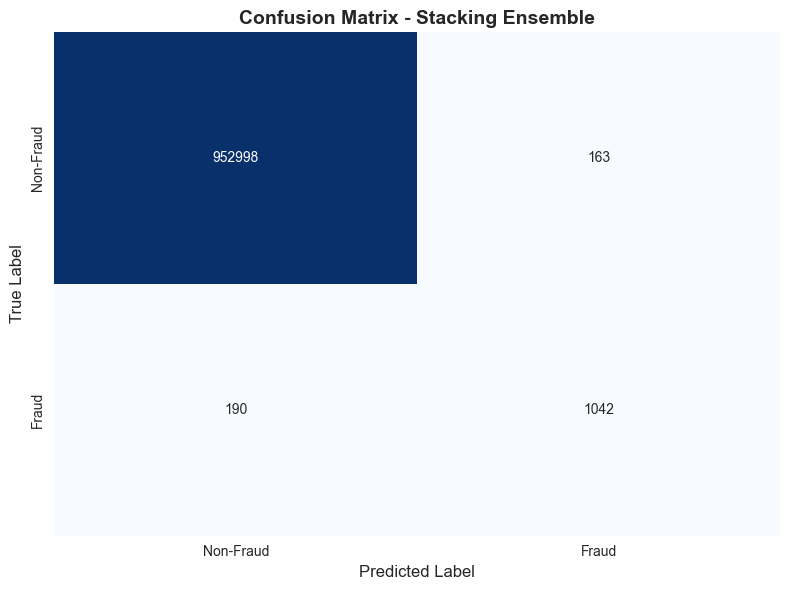

✓ Saved: stacking_ensemble_confusion_matrix.png


In [75]:
# Confusion Matrix
cm = confusion_matrix(ytest_xgb, pred_stack_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Stacking Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_confusion_matrix.png")

### 2. ROC Curve

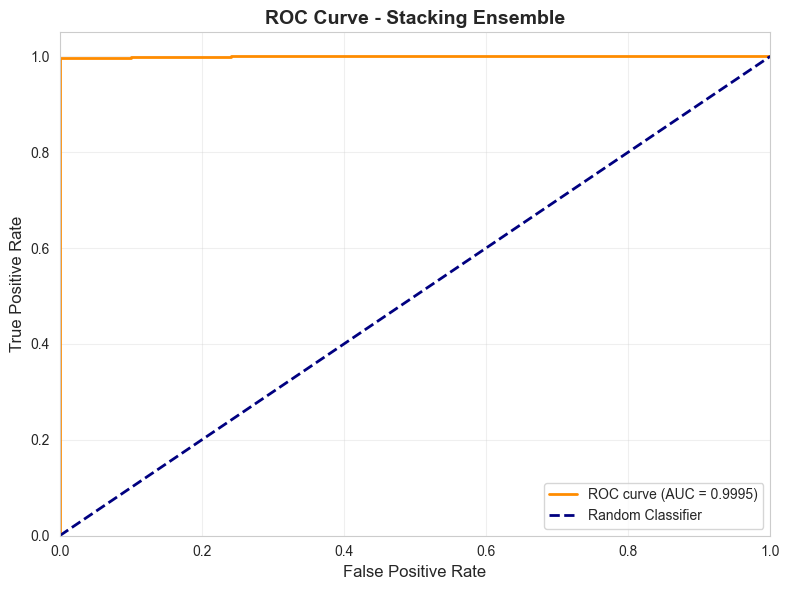

✓ Saved: stacking_ensemble_roc_curve.png


In [76]:
# ROC Curve
fpr, tpr, _ = roc_curve(ytest_xgb, p_stack_test)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Stacking Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_roc_curve.png")

### 3. Precision-Recall Curve

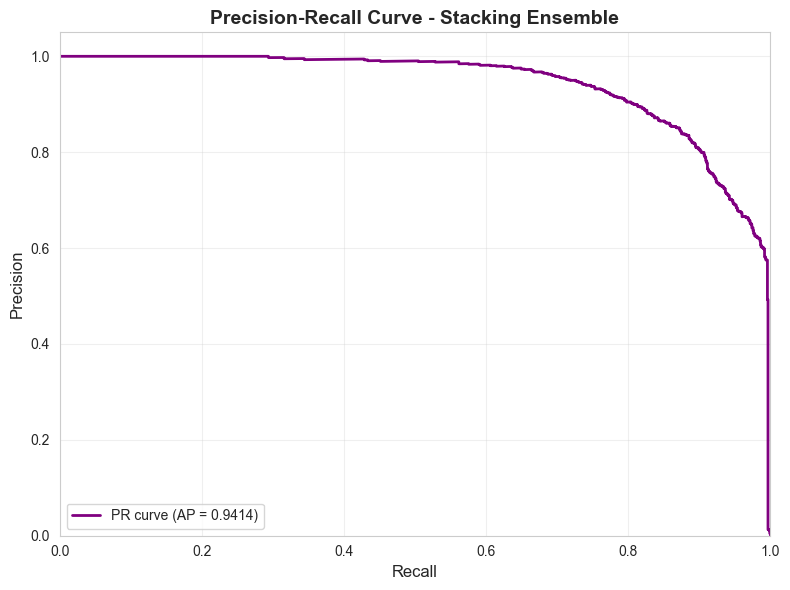

✓ Saved: stacking_ensemble_pr_curve.png


In [77]:
pr_auc = average_precision_score(ytest_xgb, p_stack_test)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ytest_xgb, p_stack_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - Stacking Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_pr_curve.png")

### 4. Feature Importance (Coefficients)

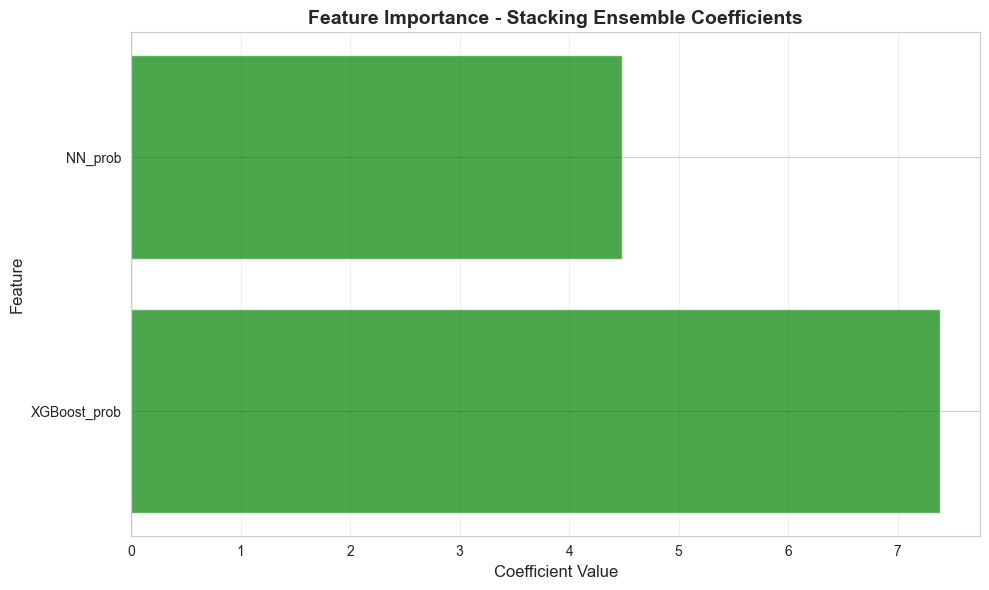

✓ Saved: stacking_ensemble_feature_importance.png


In [78]:
# Feature Importance
meta_feature_names = ["XGBoost_prob", "NN_prob"]

feature_importance = pd.DataFrame({
    "Feature": meta_feature_names,
    "Coefficient": meta.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance - Stacking Ensemble Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_feature_importance.png")

### 5. Save Metrics to CSV

In [79]:
f1 = f1_score(ytest_xgb, pred_stack_test, zero_division=0)

# Save F1 and PR-AUC to CSV for Streamlit
metrics_data = {
    'Metric': ['F1-Score', 'PR-AUC'],
    'Value': [
        f1,
        pr_auc,
    ]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(os.path.join(plots_dir, 'stacking_ensemble_metrics.csv'), index=False)
print("✓ Saved: stacking_ensemble_metrics.csv (F1-Score, PR-AUC)")
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))

✓ Saved: stacking_ensemble_metrics.csv (F1-Score, PR-AUC)

Metrics Summary:
  Metric    Value
F1-Score 0.855150
  PR-AUC 0.941432
